# DATA SCIENTIST: BREEZY_360
### Weather prediction is essential in fields like agriculture, transportation, disaster management, and daily life, and while traditional forecasting relies on numerical models, satellite data, and mathematical simulations, advancements in deep learning now enableaccurate weather prediction directly from images. This project focuses on developing a Deep Learning model using Convolutional Neural Networks (CNNs) to classify sky images into categories such as sunny, cloudy, rainy, or stormy by analyzing features like cloud patterns, color intensity, and light distribution. The process involves collecting and preprocessing weather-related images, training the CNN to recognize distinctive visual cues, and evaluating its performance through metrics like accuracyand loss. Ultimately, the project showcases how computer vision offers a fast, automated,and data-driven approach to environmental forecasting, especially in areas with limited meteorological data.

In [2]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt 
import seaborn as sns

import tensorflow
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization, AveragePooling2D
from tensorflow.keras.utils import image_dataset_from_directory

import os
import random
import shutil  #for file operation like Copying files Moving files,Deleting folders,Creating archives (zip/tar)
import warnings
warnings.filterwarnings('ignore')

In [3]:

# Path to your dataset
dataset_dir = "C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\Multi-class Weather Dataset"
output_dir = "dataset_splited"

# Create output folders
for split in ["train", "val", "test"]:
    for category in os.listdir(dataset_dir):
        os.makedirs(os.path.join(output_dir, split, category), exist_ok=True)

# Split ratios
train_split = 0.7
val_split = 0.2
test_split = 0.1

# Perform splitting
for category in os.listdir(dataset_dir):
    category_path = os.path.join(dataset_dir, category)
    images = os.listdir(category_path)
    random.shuffle(images)
    
    train_end = int(train_split * len(images))
    val_end = int((train_split + val_split) * len(images))
    
    for img in images[:train_end]:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_dir, "train", category, img))
    for img in images[train_end:val_end]:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_dir, "val", category, img))
    for img in images[val_end:]:
        shutil.copy(os.path.join(category_path, img), os.path.join(output_dir, "test", category, img))

print("✅ Dataset successfully split into train/val/test folders!")


✅ Dataset successfully split into train/val/test folders!


In [4]:
# setting the training data directory
DataDir = r"C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\train\\"

In [5]:
# intiallizing the category of classification
CATEGORIES = ["Cloudy", "Rain" ,"Shine","Sunrise"]

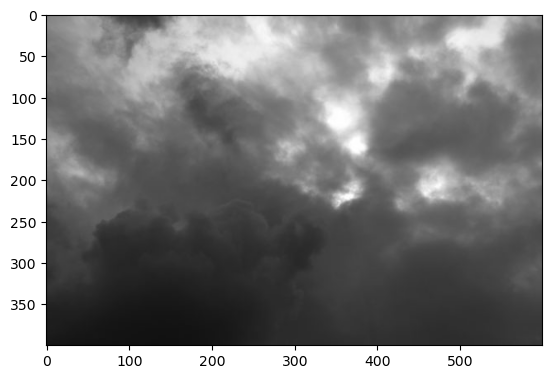

In [6]:
import cv2

for i in CATEGORIES:
    path = os.path.join(DataDir, i)
    for img in os.listdir(path):
        img_array = cv2.imread(os.path.join(path, img))  # Read image in color
        plt.imshow(img_array)  # Show original image
        plt.show()
        break
    break

In [7]:
# intializing the size of the image so that every image should be in same dimension
img_size=100

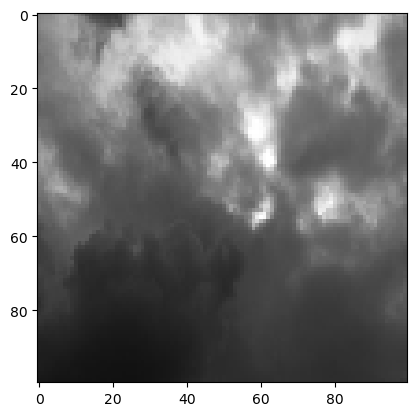

In [8]:
new_array=cv2.resize(img_array,(img_size,img_size))
plt.imshow(new_array)
plt.show()

In [9]:
training_data=[]

In [10]:
# defining the function for training data according to the categories converting the images with resizing the image into 100 x 100
# converting it into numpy arrays
def create_training_data():
    for i in CATEGORIES:
        path = os.path.join(DataDir, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                # Read image in color (BGR)
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                
                # Convert from BGR to RGB
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

                # Resize to desired size
                new_array = cv2.resize(img_array, (img_size, img_size))

                # Append to validation data
                training_data.append([new_array, class_num])

            except Exception as e:
                pass


In [11]:
create_training_data()

In [12]:
print(len(training_data))

1033


In [144]:
import random
random.shuffle(training_data)
for sample in training_data[:10]:
    print(sample)

[array([[[117, 139, 150],
        [117, 139, 150],
        [117, 139, 151],
        ...,
        [ 69,  99, 109],
        [ 72, 102, 112],
        [ 77, 107, 117]],

       [[119, 139, 150],
        [119, 139, 150],
        [119, 139, 150],
        ...,
        [ 64,  92, 103],
        [ 73, 101, 112],
        [ 76, 104, 115]],

       [[121, 141, 150],
        [119, 139, 148],
        [118, 138, 147],
        ...,
        [ 70,  99, 107],
        [ 71,  99, 108],
        [ 70,  99, 107]],

       ...,

       [[ 62,  62,  60],
        [ 62,  62,  60],
        [ 56,  56,  55],
        ...,
        [  0,   8,   5],
        [  0,   9,   6],
        [  0,   9,   6]],

       [[ 50,  51,  47],
        [ 57,  58,  54],
        [ 56,  56,  53],
        ...,
        [  0,   7,   4],
        [  0,   9,   6],
        [  0,   9,   6]],

       [[ 67,  68,  62],
        [ 55,  56,  51],
        [ 58,  59,  54],
        ...,
        [  0,   6,   4],
        [  1,   6,   4],
        [  6,   9,   7]

In [145]:
X=[]
y=[]

In [146]:
# spliting the features and labels
for features,label in training_data:
    X.append(features)
    y.append(label)

In [147]:
print(X[0].reshape(-1,img_size,img_size,3))

[[[[117 139 150]
   [117 139 150]
   [117 139 151]
   ...
   [ 69  99 109]
   [ 72 102 112]
   [ 77 107 117]]

  [[119 139 150]
   [119 139 150]
   [119 139 150]
   ...
   [ 64  92 103]
   [ 73 101 112]
   [ 76 104 115]]

  [[121 141 150]
   [119 139 148]
   [118 138 147]
   ...
   [ 70  99 107]
   [ 71  99 108]
   [ 70  99 107]]

  ...

  [[ 62  62  60]
   [ 62  62  60]
   [ 56  56  55]
   ...
   [  0   8   5]
   [  0   9   6]
   [  0   9   6]]

  [[ 50  51  47]
   [ 57  58  54]
   [ 56  56  53]
   ...
   [  0   7   4]
   [  0   9   6]
   [  0   9   6]]

  [[ 67  68  62]
   [ 55  56  51]
   [ 58  59  54]
   ...
   [  0   6   4]
   [  1   6   4]
   [  6   9   7]]]]


In [148]:
y = np.array(y)

In [149]:
X = np.array(X).reshape(-1,img_size,img_size,3)

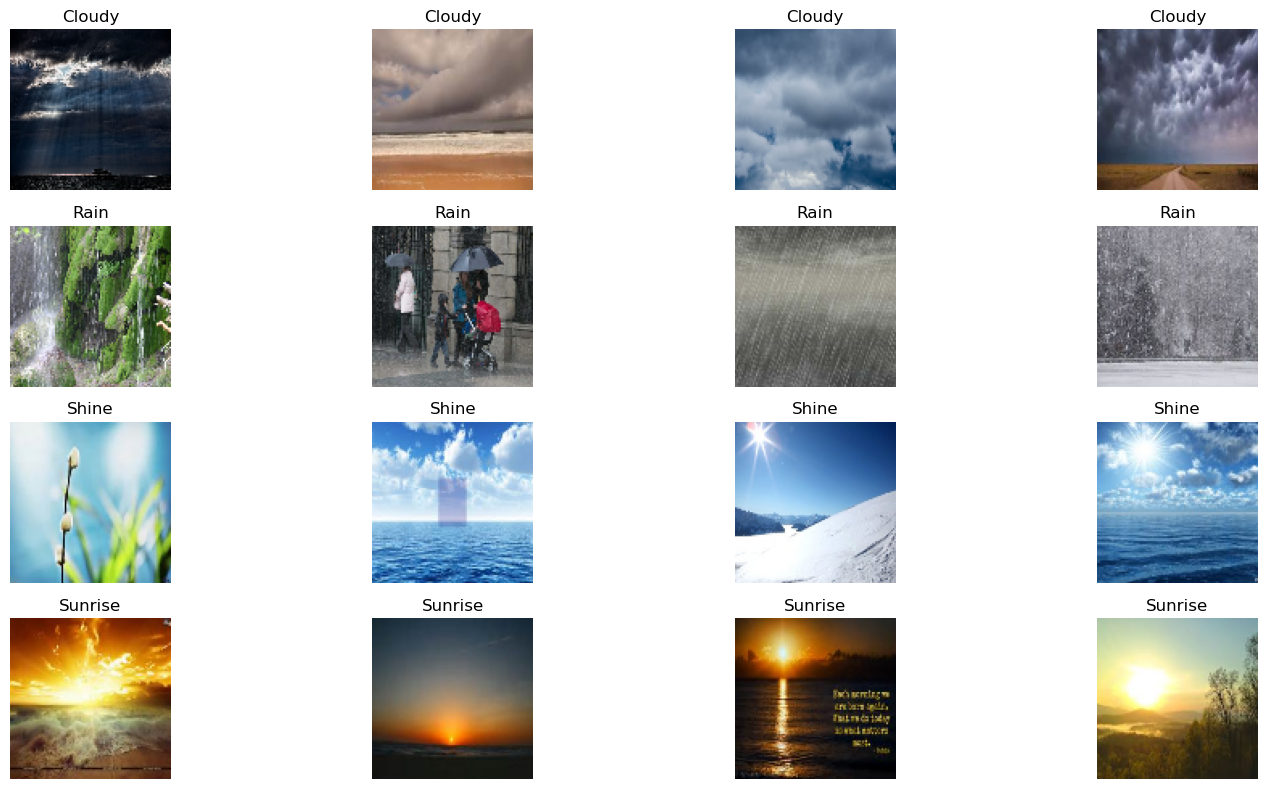

In [150]:
#for visualization of training data
class_names = ["Cloudy", "Rain" ,"Shine","Sunrise"]  

# Mapping numeric labels to real names (0 → classA, 1 → classB, etc.)
label_to_name = {i: name for i, name in enumerate(class_names)}

# Number of images per class to display
images_per_class = 4

plt.figure(figsize=(16, 8))

for row, class_label in enumerate(label_to_name.keys()):
    # Get all images for this class
    class_images = [img for img, label in training_data if label == class_label]
    
    # Randomly pick up to 4 images from this class
    selected_images = random.sample(class_images, min(images_per_class, len(class_images)))
    
    for col, img in enumerate(selected_images):
        plt.subplot(len(class_names), images_per_class, row * images_per_class + col + 1)
        plt.imshow(img)
        plt.title(label_to_name[class_label])  # ✅ Show actual class name here
        plt.axis('off')

plt.tight_layout()
plt.show()


In [151]:
# as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\val\\"

In [152]:
def create_validating_data():
    for i in CATEGORIES:
        path = os.path.join(DataDir_val, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):
            try:
                # Read image in color (BGR)
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                
                # Convert from BGR to RGB
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

                # Resize to desired size
                new_array = cv2.resize(img_array, (img_size, img_size))

                # Append to validation data
                validation_data.append([new_array, class_num])

            except Exception as e:
                pass

In [153]:
create_validating_data()
print(len(validation_data))

225


In [154]:
#import random
random.shuffle(validation_data)
for sample in validation_data[:10]:
    print(sample)

[array([[[145, 170, 200],
        [130, 163, 200],
        [ 96, 138, 180],
        ...,
        [  0, 100, 185],
        [  0, 101, 186],
        [  0, 101, 186]],

       [[135, 158, 184],
        [137, 168, 202],
        [109, 145, 183],
        ...,
        [  0, 100, 185],
        [  0, 101, 185],
        [  0, 101, 185]],

       [[133, 154, 181],
        [128, 156, 188],
        [113, 146, 182],
        ...,
        [  0,  99, 184],
        [  0,  99, 184],
        [  0,  99, 184]],

       ...,

       [[ 54,  59,   4],
        [ 49,  54,   4],
        [ 30,  36,   3],
        ...,
        [139, 115,  97],
        [113,  88,  68],
        [104,  77,  56]],

       [[ 74,  82,  22],
        [ 29,  37,   0],
        [ 21,  29,   2],
        ...,
        [149, 125, 108],
        [136, 110,  91],
        [141, 111,  90]],

       [[ 79,  92,  30],
        [ 44,  55,   9],
        [ 14,  24,   2],
        ...,
        [129, 101,  84],
        [123,  91,  73],
        [144, 106,  88]

In [155]:
X_val=[]
y_val=[]

In [156]:
for features,label in validation_data:
    X_val.append(features)
    y_val.append(label)

In [157]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1,img_size,img_size,3)

In [158]:
# importing the library for training the model and adding the neural network layers
import tensorflow as tf
import pickle

In [159]:
# Pixels value ranges from 0 to 255, 0 means black, 255 means white....
# In order to scale it down to a scale of 0 to 1, we are performing this step
X = X/255.0
x_val = X_val/255.0

In [160]:
X.shape

(786, 100, 100, 3)

In [161]:
x_val.shape

(225, 100, 100, 3)

In [162]:
#X_val = X_val.astype('float32') / 255.0


In [163]:
print("Training data range:", X.min(), X.max())
print("Validation data range:", X_val.min(), X_val.max())

Training data range: 0.0 1.0
Validation data range: 0 255


In [164]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Activation
# Initializing the neural network layer for training the model
model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(256, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())
model.add(Dense(64))
model.add(Activation('relu'))

model.add(Dropout(0.5))

# Final layer changed for 4 classes
model.add(Dense(4))
model.add(Activation('softmax'))  # Softmax for multi-class classification


In [165]:
# summary of the model
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 98, 98, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 98, 98, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 49, 49, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 47, 47, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 47, 47, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 23, 23, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 21, 21, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 21, 21, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 10, 10, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25600)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       1,638,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_13 (Activation)           │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │             260 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 4)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,009,540 (7.67 MB)

 Trainable params: 2,009,540 (7.67 MB)

 Non-trainable params: 0 (0.00 B)

In [166]:
#check the number of each class in your data set to know if class weight needed or not
for category in ["Cloudy", "Rain" ,"Shine","Sunrise"]:
    path = os.path.join(DataDir, category)
    print(category, ":", len(os.listdir(path)))

Cloudy : 210
Rain : 150
Shine : 177
Sunrise : 249


In [167]:
# display the encoding shape
print("Training X shape:", X.shape)  # Should be (num_samples, num_features)
print("Training y shape:", y.shape)  # Should be (num_samples,) or (num_samples, num_outputs)
print("Validation x_val shape:", X_val.shape)
print("Validation y_val shape:", y_val.shape)

Training X shape: (786, 100, 100, 3)
Training y shape: (786,)
Validation x_val shape: (225, 100, 100, 3)
Validation y_val shape: (225,)


In [168]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [169]:

"""from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',  # <--- use sparse version
    metrics=['accuracy']
)

hist = model.fit(
    X, y,
    batch_size=4,
    epochs=10,
    validation_data=(X_val, y_val)
)
"""

"from tensorflow.keras.optimizers import Adam\n\nmodel.compile(\n    optimizer=Adam(),\n    loss='sparse_categorical_crossentropy',  # <--- use sparse version\n    metrics=['accuracy']\n)\n\nhist = model.fit(\n    X, y,\n    batch_size=4,\n    epochs=10,\n    validation_data=(X_val, y_val)\n)\n"

In [172]:
hist = model.fit(
    X, y,
    batch_size=4,
    epochs=10,
    validation_data=(X_val, y_val))

Epoch 1/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 44s 186ms/step - accuracy: 0.5802 - loss: 0.9718 - val_accuracy: 0.5022 - val_loss: 119.4634
Epoch 2/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 36s 184ms/step - accuracy: 0.6807 - loss: 0.7296 - val_accuracy: 0.5289 - val_loss: 139.4708
Epoch 3/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 50s 254ms/step - accuracy: 0.7125 - loss: 0.6481 - val_accuracy: 0.6089 - val_loss: 81.2176
Epoch 4/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 41s 209ms/step - accuracy: 0.7188 - loss: 0.6210 - val_accuracy: 0.5689 - val_loss: 130.3965
Epoch 5/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 39s 198ms/step - accuracy: 0.7392 - loss: 0.6147 - val_accuracy: 0.6533 - val_loss: 48.5353
Epoch 6/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 38s 195ms/step - accuracy: 0.7226 - loss: 0.6117 - val_accuracy: 0.6222 - val_loss: 86.6426
Epoch 7/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 40s 188ms/step - accuracy: 0.7684 - loss: 0.5490 - val_accuracy: 0.5511 - val_loss: 157.2484
Epoch 8/10
197/197 ━━━━━━━━━━━━━━━━━━━━ 38s 193ms/step - accuracy: 0.759

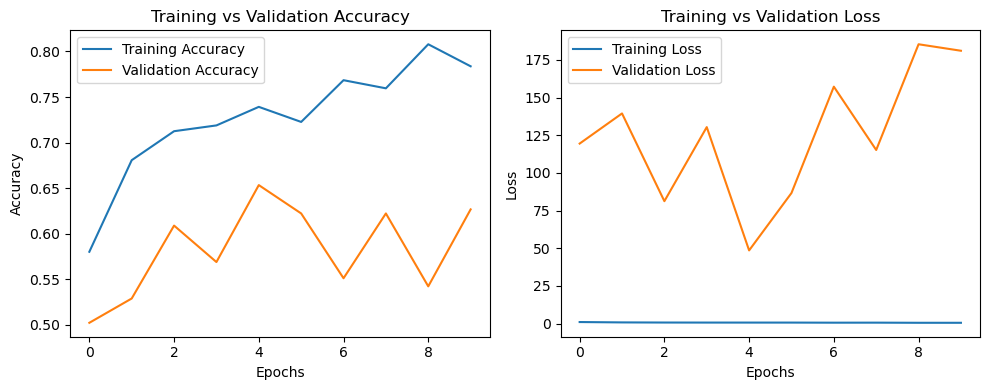

In [191]:
# 📊 Plot training vs validation accuracy
plt.figure(figsize=(10, 4))
# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [173]:
# saving the model
model.save(r"C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\weather_model.h5")

In [196]:
""" function for preparing the image for predicting the class
def prepare(image):
    img_size=100
    img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)
    img=tf.keras.preprocessing.image.load_img(image,target_size=(img_size,img_size))
    new_array=tf.keras.preprocessing.image.img_to_array(img)

    return new_array.reshape(-1,img_size,img_size,1)
"""    

' function for preparing the image for predicting the class\ndef prepare(image):\n    img_size=100\n    img_array=cv2.imread(image,cv2.IMREAD_GRAYSCALE)\n    img=tf.keras.preprocessing.image.load_img(image,target_size=(img_size,img_size))\n    new_array=tf.keras.preprocessing.image.img_to_array(img)\n\n    return new_array.reshape(-1,img_size,img_size,1)\n'

In [286]:
"""from PIL import Image
import numpy as np

# Example prepare function
def prepare(img_path):
    img = Image.open(img_path).convert('RGB')  # convert to RGB
    img = img.resize((100, 100))
    img = np.array(img)
    return img

Check the actual labels in your training data:
labels = [label for _, label in training_data]
print(set(labels))

"""

"from PIL import Image\nimport numpy as np\n\n# Example prepare function\ndef prepare(img_path):\n    img = Image.open(img_path).convert('RGB')  # convert to RGB\n    img = img.resize((100, 100))\n    img = np.array(img)\n    return img\n\nCheck the actual labels in your training data:\nlabels = [label for _, label in training_data]\nprint(set(labels))\n\n"

In [230]:
#for prediction of image 
'''image_array = prepare(image) / 255.0       # normalize
image_array = np.expand_dims(image_array, axis=0)  # shape: (1, 100, 100, 3)

prediction = model.predict(image_array)
print(prediction)
predicted_class = np.argmax(prediction, axis=1)[0]
print("Predicted class:", CATEGORIES[predicted_class])'''

'image_array = prepare(image) / 255.0       # normalize\nimage_array = np.expand_dims(image_array, axis=0)  # shape: (1, 100, 100, 3)\n\nprediction = model.predict(image_array)\nprint(prediction)\npredicted_class = np.argmax(prediction, axis=1)[0]\nprint("Predicted class:", CATEGORIES[predicted_class])'

In [277]:
model = tf.keras.models.load_model("C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\weather_model.h5")

In [282]:
image = r'C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\Multi-class Weather Dataset\\Rain\\Rain39.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
UPLOADED IMAGE:


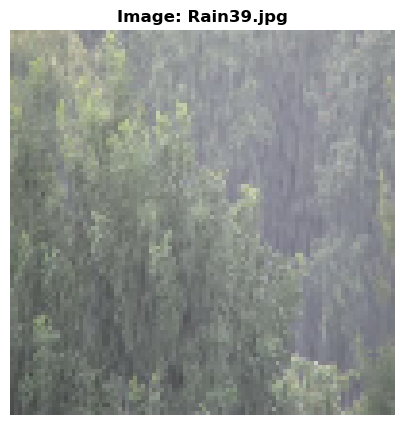

Predicted weather: Cloudy
                                
                                 
MORE INFORMATION OF THE IMAGE UPLOADED 


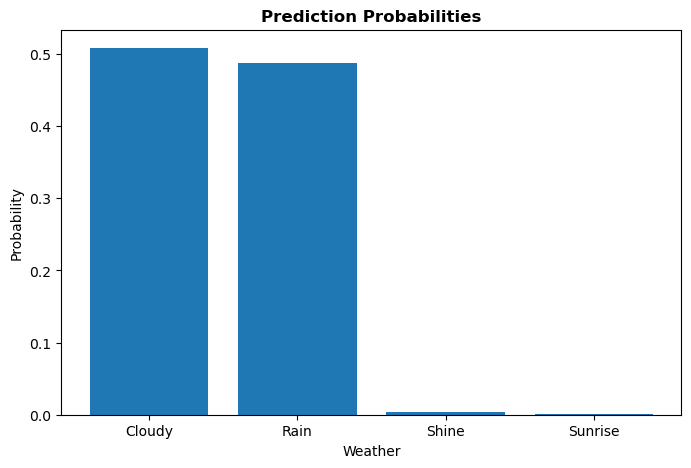

Class Probabilities (9 decimal places):
Cloudy: 0.508172095   Rain: 0.487471968
Shine: 0.004021076   Sunrise: 0.000334827


In [283]:

def prepare(image_path):
    img_array = cv2.imread(image_path)
    
    # Convert to RGB (OpenCV loads in BGR)
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    
    # Resize to match model input
    new_array = cv2.resize(img_array, (img_size, img_size))
    
    return new_array

# Load & preprocess image
image_path = image  # Replace with your image path
image_array = prepare(image_path) / 255.0  # Normalize
image_array_expanded = np.expand_dims(image_array, axis=0)  # shape -> (1, 100, 100, 3)

# Make prediction
prediction = model.predict(image_array_expanded)[0]  # shape -> (num_classes,)
predicted_class_idx = np.argmax(prediction)
predicted_class = CATEGORIES[predicted_class_idx]


# ------------------ Display Image ------------------ #
print("UPLOADED IMAGE:")
image_name = os.path.basename(image_path)
plt.figure(figsize=(6,5))
plt.imshow(image_array)
plt.title(f"Image: {image_name}",fontweight='bold')
#plt.title(f"Image: {image_name} | Predicted: {predicted_class}")
#plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()
print(f"Predicted weather: \033[1m{predicted_class}\033[0m")

print("                                ")
print("                                 ")
print("\033[mMORE INFORMATION OF THE IMAGE UPLOADED \033[0m")
# ------------------ Probability Bar Chart ------------------ #
plt.figure(figsize=(8,5))
plt.bar(CATEGORIES, prediction)
plt.title("Prediction Probabilities",fontweight='bold')
plt.xlabel("Weather")
plt.ylabel("Probability")
plt.show()

# ------------------ Print Probabilities with 9 Decimal Places ------------------ #
formatted_probs = [f"{p:.9f}" for p in prediction]

# Split into two lines
half = len(CATEGORIES) // 2
line1 = "   ".join([f"{cat}: {prob}" for cat, prob in zip(CATEGORIES[:half], formatted_probs[:half])])
line2 = "   ".join([f"{cat}: {prob}" for cat, prob in zip(CATEGORIES[half:], formatted_probs[half:])])

print("Class Probabilities (9 decimal places):")
print(line1)
print(line2)


In [14]:
# importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model

# set the path for test data
test_dir = "C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\test\\"

# define categories
CATEGORIES = ["Cloudy", "Rain" ,"Shine","Sunrise"]

# set image size
img_size = 100

# load the saved model
model = load_model("C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\weather_model.h5")

# initialize lists for storing test data
X_test = []
y_test = []

# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
    path = os.path.join(test_dir, category)
    class_num = CATEGORIES.index(category)
    for img in os.listdir(path):
        try:
            # Read image in color (BGR)
                img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_COLOR)
                
                # Convert from BGR to RGB
                img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

                # Resize to desired size
                new_array = cv2.resize(img_array, (img_size, img_size))

                # Append to te data
                X_test.append(new_array)
                y_test.append(class_num)
        except Exception as e:
            pass

# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 3)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0

# calculate test accuracy
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)

# print test accuracy
print('Test accuracy:', test_acc)


7/7 - 2s - 243ms/step - accuracy: 0.7964 - loss: 0.6757
Test accuracy: 0.7963801026344299


# Pre-Trained Models

In [236]:
# import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# define image size
img_size = 100

# load the pre-trained model (VGG16)
base_model = VGG16(input_shape=(img_size,img_size,3), include_top=False, weights='imagenet')

# freeze the layers of the pre-trained model
for layer in base_model.layers:
    layer.trainable = False

# add custom layers for classification
x = Flatten()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(64, activation='relu')(x)
predictions = Dense(4, activation='softmax')(x)

# create a new model
model = Model(inputs=base_model.input, outputs=predictions)

# compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# define the image generators for training and validation data
train_datagen = ImageDataGenerator(rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen = ImageDataGenerator(rescale=1./255)

# specify the training and validation data directories
train_dir = 'C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\train\\'
val_dir = "C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\val\\"

# create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=32, class_mode='sparse')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=32, class_mode='sparse')

# train the model
hist=model.fit(train_generator, epochs=10, validation_data=val_generator)

# evaluate the model on test data
test_dir = "C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\dataset_splited\\test\\"
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(img_size, img_size), batch_size=32, class_mode='sparse', shuffle=False)
test_loss, test_acc = model.evaluate(test_generator)
print('Test accuracy:', test_acc)


Found 786 images belonging to 4 classes.
Found 225 images belonging to 4 classes.
Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 84s 3s/step - accuracy: 0.5127 - loss: 1.1490 - val_accuracy: 0.8178 - val_loss: 0.6181
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.7570 - loss: 0.6680 - val_accuracy: 0.8844 - val_loss: 0.3459
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8384 - loss: 0.4931 - val_accuracy: 0.9067 - val_loss: 0.2729
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.8537 - loss: 0.4091 - val_accuracy: 0.9022 - val_loss: 0.2473
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.8830 - loss: 0.3353 - val_accuracy: 0.9067 - val_loss: 0.2501
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 58s 2s/step - accuracy: 0.8969 - loss: 0.2871 - val_accuracy: 0.9111 - val_loss: 0.2207
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.9211 - loss: 0.2489 - val_accuracy: 0.9333 - val_loss: 0.2129
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━

In [237]:
model.summary()

Model: "functional_146"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 100, 100, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv1 (Conv2D)                │ (None, 100, 100, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_conv2 (Conv2D)                │ (None, 100, 100, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block1_pool (MaxPooling2D)           │ (None, 50, 50, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv1 (Conv2D)                │ (None, 50, 50, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_conv2 (Conv2D)                │ (None, 50, 50, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block2_pool (MaxPooling2D)           │ (None, 25, 25, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv1 (Conv2D)                │ (None, 25, 25, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv2 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_conv3 (Conv2D)                │ (None, 25, 25, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block3_pool (MaxPooling2D)           │ (None, 12, 12, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv1 (Conv2D)                │ (None, 12, 12, 512)         │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv2 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_conv3 (Conv2D)                │ (None, 12, 12, 512)         │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block4_pool (MaxPooling2D)           │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv1 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv2 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_conv3 (Conv2D)                │ (None, 6, 6, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ block5_pool (MaxPooling2D)           │ (None, 3, 3, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 4608)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 256)                 │       1,179,904 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 18,378,638 (70.11 MB)

 Trainable params: 1,221,316 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2,442,634 (9.32 MB)

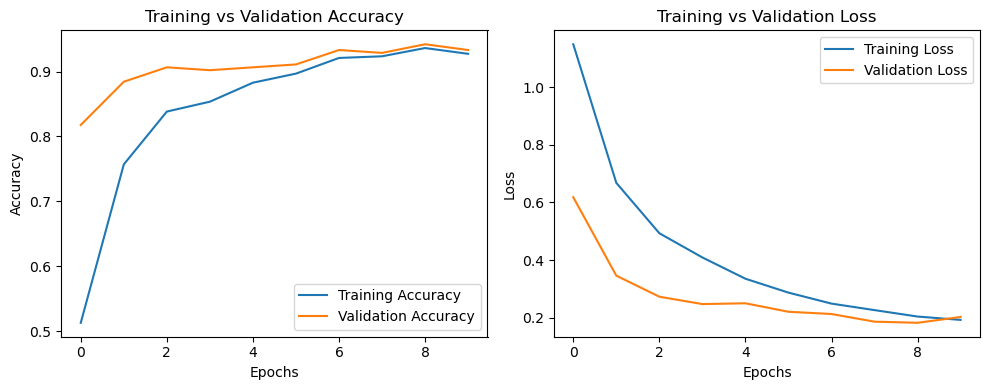

In [238]:
# 📊 Plot training vs validation accuracy
plt.figure(figsize=(10, 4))
# ---- Accuracy ----
plt.subplot(1, 2, 1)
plt.plot(hist.history['accuracy'], label='Training Accuracy')
plt.plot(hist.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# ---- Loss ----
plt.subplot(1, 2, 2)
plt.plot(hist.history['loss'], label='Training Loss')
plt.plot(hist.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [239]:
# saving the model
model.save(r"C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\weather_Trained_mode.h5")

In [240]:
model1 = tf.keras.models.load_model("C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\weather_Trained_mode.h5")

In [284]:
image = r'C:\\Users\\Admin\\OneDrive\\Desktop\\weather\\Weather\\Multi-class Weather Dataset\\Rain\\rain39.jpg'

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
UPLOADED IMAGE:


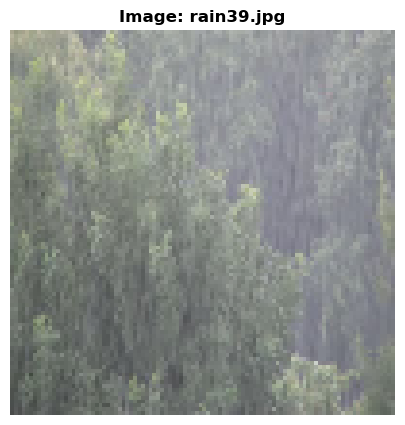

Predicted weather: Rain
                                
                                 
MORE INFORMATION OF THE IMAGE UPLOADED 


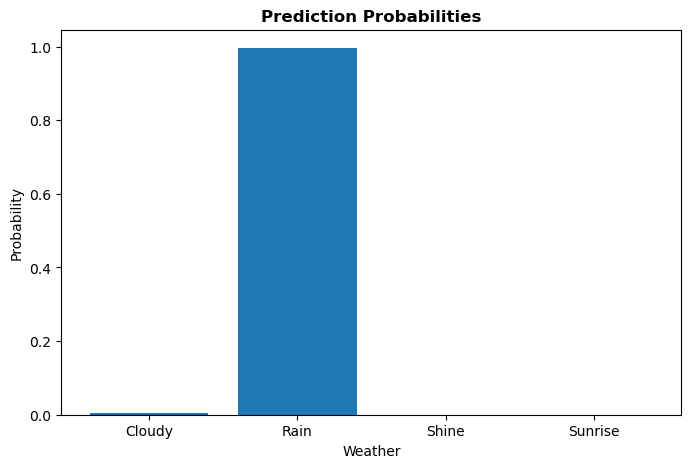

Class Probabilities (9 decimal places):
Cloudy: 0.003485503   Rain: 0.996131778
Shine: 0.000218733   Sunrise: 0.000163955


In [285]:

def prepare(image_path):
    img_array = cv2.imread(image_path)
    
    # Convert to RGB (OpenCV loads in BGR)
    img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)
    
    # Resize to match model input
    new_array = cv2.resize(img_array, (img_size, img_size))
    
    return new_array

# Load & preprocess image
image_path = image  # Replace with your image path
image_array = prepare(image_path) / 255.0  # Normalize
image_array_expanded = np.expand_dims(image_array, axis=0)  # shape -> (1, 100, 100, 3)

# Make prediction
prediction = model1.predict(image_array_expanded)[0]  # shape -> (num_classes,)
predicted_class_idx = np.argmax(prediction)
predicted_class = CATEGORIES[predicted_class_idx]


# ------------------ Display Image ------------------ #
print("UPLOADED IMAGE:")
image_name = os.path.basename(image_path)
plt.figure(figsize=(6,5))
plt.imshow(image_array)
plt.title(f"Image: {image_name}",fontweight='bold')
#plt.title(f"Image: {image_name} | Predicted: {predicted_class}")
#plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()
print(f"Predicted weather: \033[1m{predicted_class}\033[0m")

print("                                ")
print("                                 ")
print("\033[mMORE INFORMATION OF THE IMAGE UPLOADED \033[0m")
# ------------------ Probability Bar Chart ------------------ #
plt.figure(figsize=(8,5))
plt.bar(CATEGORIES, prediction)
plt.title("Prediction Probabilities",fontweight='bold')
plt.xlabel("Weather")
plt.ylabel("Probability")
plt.show()

# ------------------ Print Probabilities with 9 Decimal Places ------------------ #
formatted_probs = [f"{p:.9f}" for p in prediction]

# Split into two lines
half = len(CATEGORIES) // 2
line1 = "   ".join([f"{cat}: {prob}" for cat, prob in zip(CATEGORIES[:half], formatted_probs[:half])])
line2 = "   ".join([f"{cat}: {prob}" for cat, prob in zip(CATEGORIES[half:], formatted_probs[half:])])

print("Class Probabilities (9 decimal places):")
print(line1)
print(line2)


## In this weather prediction project, the initial CNN model achieved an accuracy of 79.82%, which was insufficient for reliable predictions. By leveraging a pre-trained model, the performance improved significantly, reaching an accuracy of 85.09%. This demonstrates that using pre-trained models can enhance prediction accuracy and reduce training time. Therefore, the pre-trained model is recommended as the final approach for weather prediction in this project.

In [13]:
#Check the actual labels in your training data:
labels = [label for _, label in training_data]
print(set(labels))

{0, 1, 2, 3}
